In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
sys.path.append("simulations")

In [5]:
import polars as pl
import jax

from analysis import housemaze_model_data
from analysis import housemaze_user_data
# from analysis import data_loading
from analysis import housemaze_analysis
from nicewebrl import dataframe

# env, example_timestep = housemaze_model_data.load_env_and_example_timestep()

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


# Simulation data

In [6]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

################
# Load model data
################
# %debug
model_df = housemaze_model_data.get_model_data(
  qlearning_path=f"{data_dir}/model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=*",
  sf_path=f"{data_dir}/model_data/usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2/seed=*",
  dyna_path=f"{data_dir}/model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=*",
  search_path=f"{data_dir}/search_algos",
  overwrite_episodes=False,
  overwrite_df=False,
)

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:66: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype)


In [5]:
# model_df = model_df.rename({'went_to_junction': 'reuse'})

# Human data

In [21]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

# searches = {
#   "Paths": f"{data_dir}/user_data/*exps*/*v1*paths*.json",
#   "Path-notell": f"{data_dir}/user_data/*exps*/*v2*r0*paths*.json",
#   "Start": f"{data_dir}/user_data/*exps*/*v3*start*.json",
#   #'Start-notell': f'{data_dir}/user_data/*exps*/*v2*r0*start*.json',
#   "Plan (Tell)": f"{data_dir}/user_data/*exps*/*v2*r1-t0-plan*.json",
#   "Plan (Don't Tell)": f"{data_dir}/user_data/*exps*/*v2*r0-t0-plan*.json",
#   "Shortcut": f"{data_dir}/user_data/*exps*/*v3*shortcut*.json",
#   # 'Shortcut-notell': f'{data_dir}/user_data/*exps*/*v2*r0*shortcut*.json',
# }
searches = {
  "Plan (Don't Tell)": f"{data_dir}/user_data/*exps*/*pilot*plan*.json",
}

valid_files = housemaze_user_data.get_valid_files(searches, verbose=True, plot=False)
user_df = housemaze_user_data.get_human_data(
    valid_files, 
    overwrite_episode_data=False,
    overwrite_episode_info=True,
    require_finished=False,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Plan (Don't Tell): 10/10 valid files


/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  pid = os.fork()
Incomplete record in /Users/wilka/git/research/results/human_dyna//user_data/exps/user=1702241248_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json
Incomplete record in /Users/wilka/git/research/results/human_dyna//user_data/exps/user=2384010369_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json
Incomplete record in /Users/wilka/git/research/results/human_dyna//user_data/exps/user=18717677

Combining results:   0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
user_df.head()

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,user,debug,exp_name,tell_reuse,reversal,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,str,str,str,i64,str,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,null
0,"""big_m4_maze_short_blind_(T,T)""",0,"""big_m4_maze_short_blind__(T,T)…","""See if faster off train path t…",4,0,1,false,29,0,1702241248,40,"""Male""","""1702241248""","""0""","""jaxmaze""",0,"""T,T""",22,1.0,23,1.0,1.430314,-0.588738,-13.540969,-0.680513,1.430314,0.847159,0.847159,0.057335,0.057335,1,null
1,"""big_m4_maze_short_blind_(T,T)""",0,"""big_m4_maze_short_blind__(T,T)…","""See if faster off train path t…",4,1,2,false,29,0,1702241248,40,"""Male""","""1702241248""","""0""","""jaxmaze""",0,"""T,T""",21,1.0,28,1.0,0.898131,-0.739801,-20.714432,-0.800465,0.898131,0.608139,0.608139,-0.430768,-0.131237,7,null
2,"""big_m4_maze_short_blind_(T,T)""",0,"""big_m4_maze_short_blind__(T,T)…","""See if faster off train path t…",4,2,3,false,29,0,1702241248,40,"""Male""","""1702241248""","""0""","""jaxmaze""",0,"""T,T""",21,1.0,21,1.0,0.974563,-0.654807,-13.750956,-0.736276,0.974563,0.37226,0.37226,-0.567378,-0.567378,0,null
3,"""big_m4_maze_short_blind_(T,T)""",0,"""big_m4_maze_short_blind__(T,T)…","""See if faster off train path t…",4,3,4,false,29,0,1702241248,40,"""Male""","""1702241248""","""0""","""jaxmaze""",0,"""T,T""",22,1.0,23,1.0,0.867525,-0.782852,-18.005602,-0.857869,0.867525,0.442125,0.252322,0.032477,0.442125,1,null
4,"""big_m4_maze_short_blind_(T,T)""",0,"""big_m4_maze_short_blind__(T,T)…","""See if faster off train path t…",4,4,5,false,29,0,1702241248,40,"""Male""","""1702241248""","""0""","""jaxmaze""",0,"""T,T""",23,1.0,23,1.0,1.499402,-0.604422,-13.901697,-0.70005,1.499402,0.365344,0.365344,-0.646245,-0.646245,0,null


In [13]:
valid_files

['/Users/wilka/git/research/results/human_dyna//user_data/exps/user=1702241248_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=2215059526_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=3275564519_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=2140777576_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=1059742079_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=2384010369_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=1221215916_name=jaxmaze_pilot-v1-r0-t0-plan_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=1871767703_name=jaxmaze_pilot-v1-r0-t0-plan

# Analysis

In [23]:
# !pip install statsmodels

In [14]:
# data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# # %debug
# housemaze_analysis.experiment_1_results(
#   user_df,
#   model_df,
#   save_dir=save_dir,
#   tell_reuse=1,
#   display_figs=True,
#   save_figs=True,
#   n_simulations=1,
#   verbosity=1,
# )

In [57]:
# data_dir = '/Users/wilka/git/research/results/human_dyna/'
# save_dir = f'{data_dir}/analysis_results/'
# housemaze_analysis.experiment_1_results(
#     user_df,
#     model_df,
#     save_dir=save_dir,
#     tell_reuse=0,
#     display_figs=False,
#     save_figs=True)

In [15]:
# data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"


# housemaze_analysis.experiment_2_results(
#   user_df,
#   model_df,
#   save_dir=save_dir,
#   tell_reuse=1,
#   save_figs=True,
#   verbosity=1,
# )
# # housemaze_analysis.experiment_2_results(
# #     user_df,
# #     model_df,
# #     save_dir=save_dir,
# #     tell_reuse=0,
# #     save_figs=True)

In [68]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_3_results(
  user_df,
  model_df,
  filter_columns=[],
  save_dir=save_dir,
  tell_reuse=1,
  save_figs=True,
  verbosity=1,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Experiment 3 Statistical Analysis


log_first_rt:
N = 25 participants
Mean difference = 0.276 (SE: 0.118)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 215.000
p = 0.082

Effect Size (r):
0.278

Power Analysis:
Achieved power with current N=25: 0.834
Required sample sizes:
  80% power: N ≥ 21
  90% power: N ≥ 29
  95% power: N ≥ 36

log_avg_rt:
N = 25 participants
Mean difference = -0.015 (SE: 0.023)

Normality Test (Shapiro-Wilk):
p = 0.636 (Normal distribution)

Paired t-test:
statistic = -0.667
p = 0.744

Effect Size (Cohen's d):
-0.133

Power Analysis:
Achieved power with current N=25: 0.159
Required sample sizes:
  80% power: N ≥ 350
  90% power: N ≥ 484
  95% power: N ≥ 611



No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


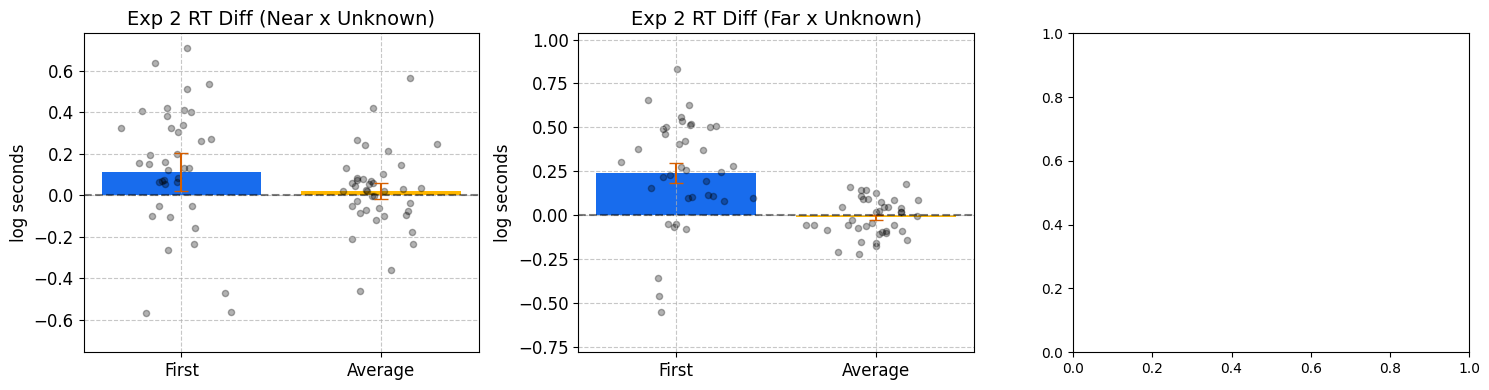

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze

In [24]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_4_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  filter_columns=[],
  save_figs=True,
  display_figs=True,
    tell_reuse_options=[0],
)